# Model Preprocessing and Combination with Human Data

## 1. Preprocessing and Cleanup of the data 

### A. First let's read in each experiment and combine the convnext and vit results for each experiment

In [62]:
# Clear all variables from the workspace (preliminary step to ensure a clean environment)
%reset -f

import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Set the core path
core_path = "/zpool/vladlab/data_drive/glint_master/data/model_data/"

# Create empty lists to store the dataframes for each model and experiment

all_models_adult_familiar_dfs = []

all_models_adult_novel_dfs = []

all_models_child_familiar_dfs = []

all_models_child_novel_dfs = []



# 1. Adult Familiar
convnext_files_adult_familiar = f"{core_path}/familiar/convnext_KNN_all_conditions_9way.csv" # Path ConvNext
vit_files_adult_familiar = f"{core_path}/familiar/vit_KNN_all_conditions_9way.csv" # Path ViT

# A. Read the CSV files into dataframes and append to the respective lists
adult_familiar_convnext = pd.read_csv(convnext_files_adult_familiar) #Read ConvNext CSV
adult_familiar_vit = pd.read_csv(vit_files_adult_familiar) #Read ViT CSV

# B. Append the dataframes to the respective lists
all_models_adult_familiar_dfs = pd.concat([adult_familiar_convnext, adult_familiar_vit], ignore_index=True) # Concatenate ConvNext and ViT dataframes and append to the list

# 2. Adult Novel
convnext_files_adult_novel = f"{core_path}/novel/convnext_4way_novel_final.csv"
vit_files_adult_novel = f"{core_path}/novel/vit_4way_novel_final.csv"

# A. Read the CSV files into dataframes
adult_novel_convnext = pd.read_csv(convnext_files_adult_novel)
adult_novel_vit = pd.read_csv(vit_files_adult_novel)

# B. Append the dataframes to the respective lists
all_models_adult_novel_dfs = pd.concat([adult_novel_convnext, adult_novel_vit], ignore_index=True) # Concatenate ConvNext and ViT dataframes and append to the list
all_models_adult_novel_dfs = all_models_adult_novel_dfs.drop(columns=['acc']) # Rename the filtered_acc column to filtered_acc_novel for clarity

# 3. Child Familiar
convnext_files_child_familiar = f"{core_path}/child_familiar/convnext_KNN_all_conditions_2way_new.csv"
vit_files_child_familiar = f"{core_path}/child_familiar/vit_KNN_all_conditions_2way_new.csv"

# A. Read the CSV files into dataframes
child_familiar_convnext = pd.read_csv(convnext_files_child_familiar)
child_familiar_vit = pd.read_csv(vit_files_child_familiar)

# B. Append the dataframes to the respective lists
all_models_child_familiar_dfs = pd.concat([child_familiar_convnext, child_familiar_vit], ignore_index=True) # Concatenate ConvNext and ViT dataframes and append to the list

# 4. Child Novel
convnext_files_child_novel = f"{core_path}/child_novel/convnext_3way_novel_final.csv"
vit_files_child_novel = f"{core_path}/child_novel/vit_3way_novel_final.csv"

# A. Read the CSV files into dataframes
child_novel_convnext = pd.read_csv(convnext_files_child_novel)
child_novel_vit = pd.read_csv(vit_files_child_novel)

# B. Append the dataframes to the respective lists
all_models_child_novel_dfs = pd.concat([child_novel_convnext, child_novel_vit], ignore_index=True) # Concatenate ConvNext and ViT dataframes and append to the list




### B. Now, let's ensure all our data sheet have the same column headers and information

#### Functions for standardizing dataframes

In [63]:
'''
At this point, we have four dataframes: all_models_adult_familiar_dfs, 
all_models_adult_novel_dfs, all_models_child_familiar_dfs, and all_models_child_novel_dfs.
Each dataframe contains the concatenated results from both ConvNext and ViT models for the respective experiment.

We need to ensure that the dataframes have the same structure and columns to facilitate
further analysis and for our figure generation script.

To do this, we will create a mapping of the column names and ensure that all dataframes have the same columns in the same order.
We will also add a column to each dataframe to indicate the model type (ConvNext or ViT) 
and the experiment type (Adult Familiar, Adult Novel, Child Familiar, Child Novel) for easier identification during analysis.

Finally, we will save these processed dataframes as CSV files for use in our figure generation script.
'''

# Define a function to standardize the column names and add model and experiment type columns

def standardize_dataframe(df, adult_or_child):

    # Standardize column names (this is an example, adjust as needed based on actual column names)
    df = df.rename(columns={
        'model': 'id', # change model to id for consistency with human data
        'experiment': 'experiment_label', # change experiment to experiment_label for consistency with human data
        'test_animacy': 'animacy', # change test_animacy to animacy for consistency with human data
        'acc': 'filtered_acc', # change acc to filtered_acc for consistency with human data
        
        # Add more columns as needed
    })
    
    # Fix the familiar value in the familiar experiment, as it was read in as "['familiar']" instead of "familiar"
    if df['experiment_label'].iloc[0] == "['familiar']":
        df["experiment_label"] = df["experiment_label"].replace("['familiar']", "familiar")

    if 'animacy' not in df.columns and df['experiment_label'].iloc[0] == 'novel':
        df['animacy'] = 'inanim_artificial' # Add animacy column with inanimate/artificial value for novel experiment

    # Add model type and experiment type columns
    df['adult_or_child'] = adult_or_child # Add a column to indicate whether it's an adult or child model (extra precautionary step, as we have separate dataframes for adult and child models)

    
    return df

'''
This function takes a dataframe and groups it by the relevant columns (experiment_label, id, condition, animacy) 
and calculates the mean of the filtered_acc column and counts the number of trials after exclusion for each group.
It also adds a stimulus_duration column (which is set to None for now, as we don't have this information for the models)
and a model_or_human column (which is set to 'model' for all rows in these dataframes).
Finally, it reorders the columns to match the structure of the human dataframes for easier analysis and figure generation.

'''
def group_and_aggregate(df):
    df = (df.groupby(['experiment_label', 'id', 'condition', 'animacy'], as_index=False)['filtered_acc']
      .agg(filtered_acc="mean",num_trials_after_exclusion="count")
      )
    df['stimulus_duration'] = None
    df['model_or_human'] = 'model'
    df = df.reindex(columns=[
    "experiment_label", "id", "condition", "stimulus_duration", "animacy",  "filtered_acc", "num_trials_after_exclusion", "model_or_human"
])
    return df

#### Use the function to standardize the dataframes and save the raw unprocessed dfs

Reason we save here is to have a copy of the unprocessed dataframes that contain all the model relevant information. 

Following this step, we will group the dfs by condition and animacy, like in the human experiments for the actual figures

In [64]:
# Standardize each dataframe and add model

# 1. Adult Familiar

# A. Standardize the dataframes
adult_familiar_all_models_df = standardize_dataframe(all_models_adult_familiar_dfs, 'adult')

# B.  Save the standardized dataframe as a CSV file into master_glint directory 
adult_familiar_all_models_df.to_csv('/zpool/vladlab/data_drive/glint_master/data/model_data/familiar/models_combined/adult_familiar_all_models_raw.csv', index=False)

# 2. Adult Novel
# A. Standardize the dataframes
adult_novel_all_models_df = standardize_dataframe(all_models_adult_novel_dfs, 'adult')

# B. Save the standardized dataframe as a CSV file into master_glint directory
adult_novel_all_models_df.to_csv('/zpool/vladlab/data_drive/glint_master/data/model_data/novel/models_combined/adult_novel_all_models_raw.csv', index=False)

# 3. Child Familiar
# A. Standardize the dataframes
child_familiar_all_models_df = standardize_dataframe(all_models_child_familiar_dfs, 'child')

# B. Save the standardized dataframe as a CSV file into master_glint directory
child_familiar_all_models_df.to_csv('/zpool/vladlab/data_drive/glint_master/data/model_data/child_familiar/models_combined/child_familiar_all_models_raw.csv', index=False)
# 4. Child Novel
# A. Standardize the dataframes
child_novel_all_models_df = standardize_dataframe(all_models_child_novel_dfs, 'child')

# B. Save the standardized dataframe as a CSV file into master_glint directory
child_novel_all_models_df.to_csv('/zpool/vladlab/data_drive/glint_master/data/model_data/child_novel/models_combined/child_novel_all_models_raw.csv', index=False)


### C. Now that we have standardized the data frames, let's calculate the average performance on each condition

This is similar to how the human data are processed, and to be able to compare the models and humans we will need to do the same for the models

In [65]:
# run the group_and_aggregate function on each of the dataframes to get the final dataframes we will next combine with the human data 

# 1. Adult Familiar
adult_familiar_grouped = group_and_aggregate(df=adult_familiar_all_models_df)

# 2. Adult Novel
adult_novel_grouped = group_and_aggregate(df=adult_novel_all_models_df)

# 3. Child Familiar
child_familiar_grouped = group_and_aggregate(df=child_familiar_all_models_df)

# 4. Child Novel
child_novel_grouped = group_and_aggregate(df=child_novel_all_models_df)


### Do a quick visualization to see how the data looks

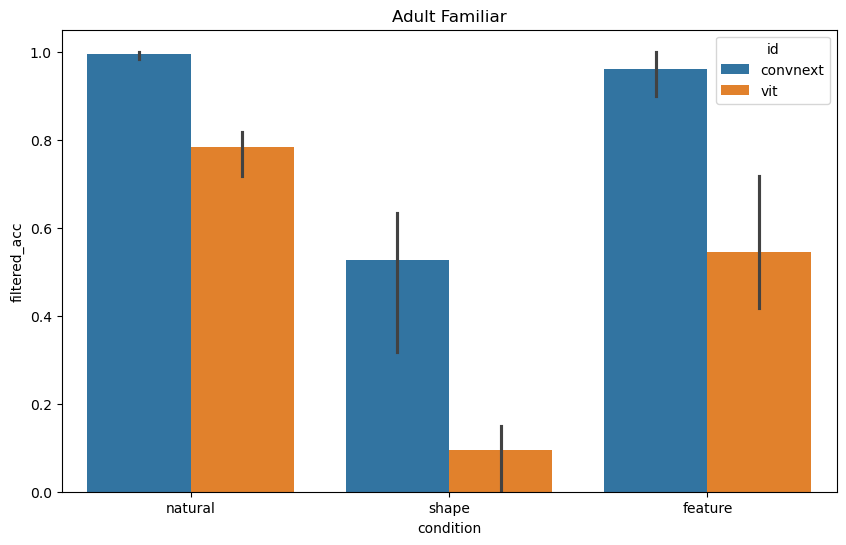

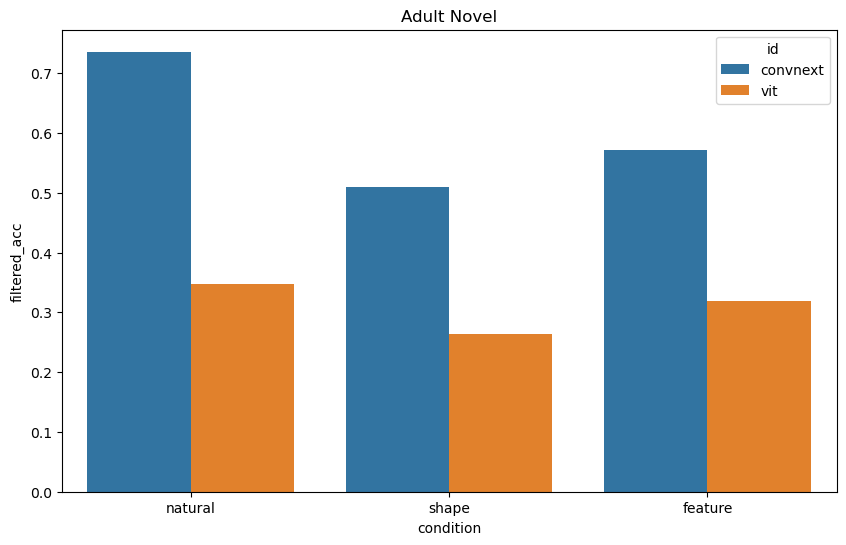

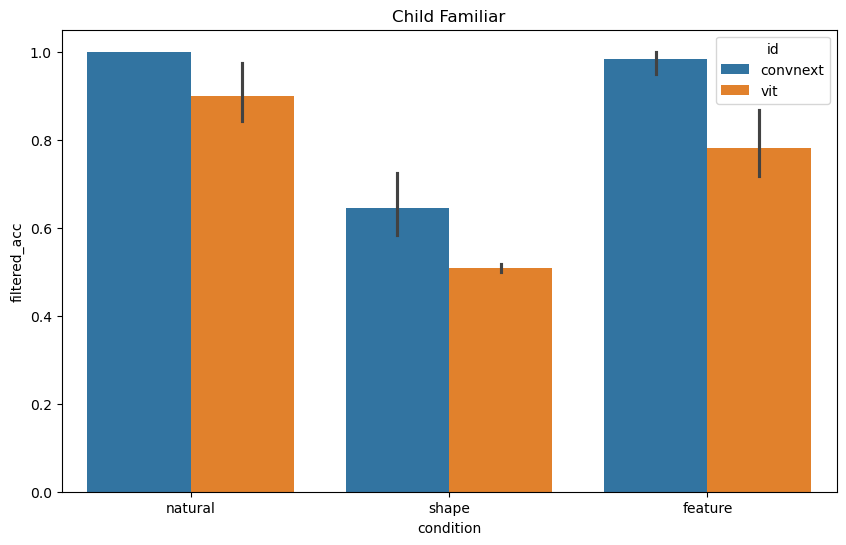

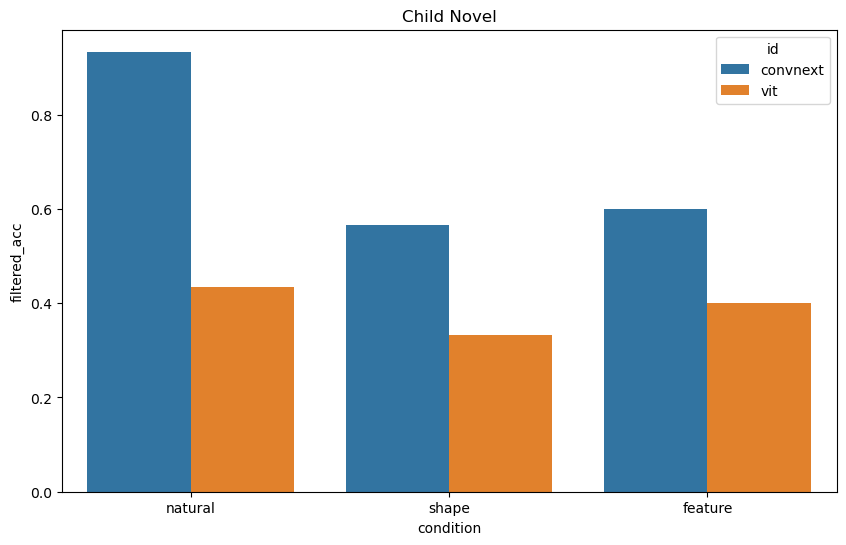

In [76]:
condition_order = ['natural', 'shape', 'feature']
dfs = [('Adult Familiar', adult_familiar_grouped), ('Adult Novel', adult_novel_grouped), ('Child Familiar', child_familiar_grouped), ('Child Novel', child_novel_grouped)]
for title, df in dfs:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="condition", y="filtered_acc", hue="id", order=condition_order)
    plt.title(title)

### Save the Model Summary Data

In [78]:
# 1. Adult Familiar
adult_familiar_grouped.to_csv("/zpool/vladlab/data_drive/glint_master/data/model_data/summary_csv/adult_familiar_model_summary.csv", index=False)


# 2. Adult Novel
adult_novel_grouped.to_csv("/zpool/vladlab/data_drive/glint_master/data/model_data/summary_csv/adult_novel_model_summary.csv", index=False)


# 3. Child Familiar
child_familiar_grouped.to_csv("/zpool/vladlab/data_drive/glint_master/data/model_data/summary_csv/child_familiar_model_summary.csv", index=False)


# 4. Child Novel
child_novel_grouped.to_csv("/zpool/vladlab/data_drive/glint_master/data/model_data/summary_csv/child_novel_model_summary.csv", index=False)

# WORK IN PROGRESS 
Now let's combine the model with the human data

In [2]:
# import the human data 
human_familiar_file_path = '/zpool/vladlab/data_drive/glint_master/data/adult_data/summary_data_csv/familiar_glint_original_cleaned.csv' # Path
human_familiar_df = pd.read_csv(human_familiar_file_path) #Read in data
human_familiar_df = human_familiar_df.rename(columns={"sub": "id"}) #Rename sub to id
human_familiar_df["model_or_human"] = "human" #Add identifying variable for figures


human_novel_file_path = '/zpool/vladlab/data_drive/glint_master/data/adult_data/summary_data_csv/novel_glint_original_cleaned.csv' # Path 
human_novel_df = pd.read_csv(human_novel_file_path) # Read in data
human_novel_df = human_novel_df.rename(columns={"sub": "id"}) #Rename sub to id
human_novel_df["model_or_human"] = "human" #Add identifying variable for figures

combined_familiar_df = pd.concat([human_familiar_df, familiar_model_summary_df], ignore_index = True ) #Combine them

combined_novel_df = pd.concat([human_novel_df, novel_model_summary_df], ignore_index = True) # Combine them


### Save the Data

In [6]:
combined_familiar_df.to_csv("/zpool/vladlab/data_drive/glint_master/data/model_data/summary_csv/human_model_combo_familiar_summary.csv", index=False)

combined_novel_df.to_csv("/zpool/vladlab/data_drive/glint_master/data/model_data/summary_csv/human_model_combo_novel_summary.csv", index=False)

### Quick plot and stats

In [6]:
condition_order = ["natural", "shape", "feature"]


sns.barplot(
    data= combined_novel_df, 
    x = "condition",
    y = "filtered_acc",
    hue = "model_or_human",
    order = condition_order,
    errorbar="ci")

NameError: name 'combined_novel_df' is not defined

In [5]:
stats = (combined_novel_df
         .groupby(["model_or_human", "condition"])["filtered_acc"]
         .agg(n="count", sd="std", mean="mean")
         .reset_index())
stats["se"] = stats["sd"] / (stats["n"] ** 0.5)
stats["ci95"] = 1.96 * stats["se"]
print(stats)

   model_or_human condition     n        sd      mean        se      ci95
0        clip_vit   feature  6480  0.498087  0.455864  0.006188  0.012128
1        clip_vit   natural  6480  0.463110  0.688580  0.005753  0.011276
2        clip_vit     shape  6480  0.494000  0.422531  0.006137  0.012028
3        convnext   feature  6480  0.494884  0.571605  0.006148  0.012050
4        convnext   natural  6480  0.440939  0.735802  0.005478  0.010736
5        convnext     shape  6480  0.499953  0.509259  0.006211  0.012173
6           human   feature    50  0.220227  0.470153  0.031145  0.061044
7           human   natural    50  0.224071  0.699301  0.031688  0.062109
8           human     shape    50  0.252457  0.646906  0.035703  0.069977
9             vit   feature  6480  0.465938  0.318519  0.005788  0.011345
10            vit   natural  6480  0.476025  0.346914  0.005913  0.011590
11            vit     shape  6480  0.440443  0.263272  0.005471  0.010724
12     vit_dinov2   feature  6480  0.4